In [1]:
"""
streamflix_complete.py
======================
StreamFlix Video Streaming Service Management System
Complete implementation in a single file for Google Colab.

Author: [Your Name]
Date: [Submission Date]
Course: ICS220 - Programming Fundamentals
Assignment: 2
"""

# ════════════════════════════════════════════════════════════
# IMPORTS
# ════════════════════════════════════════════════════════════
from datetime import date, timedelta, datetime


# ════════════════════════════════════════════════════════════
# CLASS: Content
# ════════════════════════════════════════════════════════════
class Content:
    """Represents a video content item on StreamFlix."""

    _id_counter = 1000

    def __init__(self, title, genre, release_year, duration, rating, content_type, premium=False, availability_status=True):
        if not (0.0 <= rating <= 10.0):
            raise ValueError("Rating must be between 0.0 and 10.0.")
        valid_types = ['Movie', 'TV Series', 'Documentary']
        if content_type not in valid_types:
            raise ValueError(f"content_type must be one of {valid_types}.")
        Content._id_counter += 1
        self.__content_id = Content._id_counter
        self.__title = title
        self.__genre = genre
        self.__release_year = release_year
        self.__duration = duration
        self.__rating = rating
        self.__availability_status = availability_status
        self.__content_type = content_type
        self.__premium = premium

    def get_content_id(self):
        return self.__content_id

    def get_title(self):
        return self.__title

    def get_genre(self):
        return self.__genre

    def get_release_year(self):
        return self.__release_year

    def get_duration(self):
        return self.__duration

    def get_rating(self):
        return self.__rating

    def is_available(self):
        return self.__availability_status

    def get_content_type(self):
        return self.__content_type

    def is_premium(self):
        return self.__premium

    def get_details(self):
        return {
            'content_id': self.__content_id, 'title': self.__title,
            'genre': self.__genre, 'release_year': self.__release_year,
            'duration': self.__duration, 'rating': self.__rating,
            'availability_status': self.__availability_status,
            'content_type': self.__content_type, 'premium': self.__premium
        }

    def update_details(self, **kwargs):
        allowed = {'title', 'genre', 'release_year', 'duration', 'rating',
                    'availability_status', 'content_type', 'premium'}
        for key, value in kwargs.items():
            if key not in allowed:
                raise ValueError(f"Invalid attribute: {key}")
            if key == 'rating' and not (0.0 <= value <= 10.0):
                raise ValueError("Rating must be between 0.0 and 10.0.")
            if key == 'content_type' and value not in ['Movie', 'TV Series', 'Documentary']:
                raise ValueError("content_type must be Movie, TV Series, or Documentary.")
            setattr(self, f'_Content__{key}', value)

    def set_availability(self, status):
        self.__availability_status = status

    def __str__(self):
        status = "Available" if self.__availability_status else "Unavailable"
        premium_tag = " [PREMIUM]" if self.__premium else ""
        return (f"[{self.__content_id}] {self.__title} ({self.__content_type}) "
                f"- {self.__genre}, {self.__release_year}, {self.__duration}min, "
                f"Rating: {self.__rating}/10, {status}{premium_tag}")


# ════════════════════════════════════════════════════════════
# CLASS: ContentCatalogue
# ════════════════════════════════════════════════════════════
class ContentCatalogue:
    """Manages the full catalogue of Content items."""

    def __init__(self):
        self.__catalogue = []

    def add_content(self, content):
        if not isinstance(content, Content):
            raise TypeError("Only Content instances can be added.")
        for c in self.__catalogue:
            if c.get_content_id() == content.get_content_id():
                raise ValueError(f"Content ID {content.get_content_id()} already exists.")
        self.__catalogue.append(content)

    def remove_content(self, content_id):
        for i, c in enumerate(self.__catalogue):
            if c.get_content_id() == content_id:
                self.__catalogue.pop(i)
                return
        raise ValueError(f"Content ID {content_id} not found.")

    def search_content(self, title):
        return [c for c in self.__catalogue if title.lower() in c.get_title().lower()]

    def filter_by_genre(self, genre):
        return [c for c in self.__catalogue if c.get_genre().lower() == genre.lower()]

    def filter_by_type(self, content_type):
        return [c for c in self.__catalogue if c.get_content_type().lower() == content_type.lower()]

    def get_all_content(self):
        return list(self.__catalogue)

    def __str__(self):
        if not self.__catalogue:
            return "ContentCatalogue: [Empty]"
        lines = ["=" * 60, "       StreamFlix Content Catalogue", "=" * 60]
        for c in self.__catalogue:
            lines.append(str(c))
        lines.append("=" * 60)
        lines.append(f"Total items: {len(self.__catalogue)}")
        return "\n".join(lines)


# ════════════════════════════════════════════════════════════
# CLASS: User
# ════════════════════════════════════════════════════════════
class User:
    """Represents a registered StreamFlix user."""

    _id_counter = 2000

    def __init__(self, name, email, password, subscription_status="Inactive"):
        if not name.strip():
            raise ValueError("Name cannot be empty.")
        if not email.strip() or "@" not in email:
            raise ValueError("A valid email address is required.")
        if len(password) < 6:
            raise ValueError("Password must be at least 6 characters.")
        User._id_counter += 1
        self.__user_id = User._id_counter
        self.__name = name.strip()
        self.__email = email.strip()
        self.__password = password
        self.__subscription_status = subscription_status
        self.__viewing_history = []
        self.__notifications = []

    def get_user_id(self):
        return self.__user_id

    def get_name(self):
        return self.__name

    def get_email(self):
        return self.__email

    def get_subscription_status(self):
        return self.__subscription_status

    def get_viewing_history(self):
        return list(self.__viewing_history)

    def get_notifications(self):
        return list(self.__notifications)

    def set_subscription_status(self, status):
        allowed = ['Active', 'Inactive', 'Cancelled']
        if status not in allowed:
            raise ValueError(f"Status must be one of {allowed}.")
        self.__subscription_status = status

    def create_account(self):
        print(f"Account created successfully for {self.__name} (ID: {self.__user_id}).")

    def update_profile(self, name=None, email=None):
        if name is not None:
            if not name.strip():
                raise ValueError("Name cannot be empty.")
            self.__name = name.strip()
        if email is not None:
            if not email.strip() or "@" not in email:
                raise ValueError("A valid email address is required.")
            self.__email = email.strip()

    def reset_password(self, new_password):
        if len(new_password) < 6:
            raise ValueError("Password must be at least 6 characters.")
        self.__password = new_password

    def add_notification(self, notification):
        self.__notifications.append(notification)

    def add_viewing_record(self, record):
        self.__viewing_history.append(record)

    def __str__(self):
        return (f"User[{self.__user_id}] {self.__name} | "
                f"Email: {self.__email} | Status: {self.__subscription_status}")


# ════════════════════════════════════════════════════════════
# CLASS: Admin (Inherits User)
# ════════════════════════════════════════════════════════════
class Admin(User):
    """Administrator with elevated management privileges."""

    def __init__(self, name, email, password, admin_level="Standard"):
        super().__init__(name, email, password, subscription_status="Active")
        self.__admin_level = admin_level

    def get_admin_level(self):
        return self.__admin_level

    def manage_user_account(self, user, action):
        actions = ['reset_password', 'deactivate', 'activate']
        if action not in actions:
            raise ValueError(f"Action must be one of {actions}.")
        if action == 'reset_password':
            user.reset_password("Default123")
            print(f"Admin reset password for {user.get_name()}.")
        elif action == 'deactivate':
            user.set_subscription_status("Inactive")
            print(f"Admin deactivated account for {user.get_name()}.")
        elif action == 'activate':
            user.set_subscription_status("Active")
            print(f"Admin activated account for {user.get_name()}.")

    def manage_content(self, catalogue, content, action):
        if action == 'add':
            catalogue.add_content(content)
            print(f"Admin added content: {content.get_title()}.")
        elif action == 'remove':
            catalogue.remove_content(content)
            print(f"Admin removed content with ID: {content}.")
        else:
            raise ValueError("Action must be 'add' or 'remove'.")

    def manage_pricing_plan(self, plan, action):
        if action == 'update_price':
            print(f"Admin updated pricing for plan: {plan}.")
        elif action == 'deactivate':
            print(f"Admin deactivated plan: {plan}.")
        else:
            raise ValueError("Action must be 'update_price' or 'deactivate'.")

    def delete_expired_accounts(self, users):
        active = [u for u in users if u.get_subscription_status() != 'Cancelled']
        removed = len(users) - len(active)
        print(f"Admin deleted {removed} expired account(s).")
        return active

    def __str__(self):
        return (f"Admin[{self.get_user_id()}] {self.get_name()} | "
                f"Level: {self.__admin_level} | Email: {self.get_email()}")


# ════════════════════════════════════════════════════════════
# CLASS: SubscriptionPlan
# ════════════════════════════════════════════════════════════
class SubscriptionPlan:
    """Represents a subscription tier."""

    _id_counter = 3000

    def __init__(self, plan_name, price, access_level, duration_days=30, features=None):
        if price < 0:
            raise ValueError("Price cannot be negative.")
        if access_level not in (1, 2, 3):
            raise ValueError("Access level must be 1, 2, or 3.")
        SubscriptionPlan._id_counter += 1
        self.__plan_id = SubscriptionPlan._id_counter
        self.__plan_name = plan_name
        self.__price = price
        self.__access_level = access_level
        self.__duration_days = duration_days
        self.__features = features if features else []

    def get_plan_id(self):
        return self.__plan_id

    def get_plan_name(self):
        return self.__plan_name

    def get_price(self):
        return self.__price

    def get_access_level(self):
        return self.__access_level

    def get_duration_days(self):
        return self.__duration_days

    def get_features(self):
        return list(self.__features)

    def get_plan_details(self):
        return {
            'plan_id': self.__plan_id, 'plan_name': self.__plan_name,
            'price': self.__price, 'access_level': self.__access_level,
            'duration_days': self.__duration_days, 'features': self.__features
        }

    def update_price(self, new_price):
        if new_price < 0:
            raise ValueError("Price cannot be negative.")
        self.__price = new_price

    def __str__(self):
        return (f"Plan[{self.__plan_id}] {self.__plan_name} - "
                f"${self.__price:.2f}/month | Level: {self.__access_level} | "
                f"Duration: {self.__duration_days} days")


# ════════════════════════════════════════════════════════════
# CLASS: Subscription
# ════════════════════════════════════════════════════════════
class Subscription:
    """Links a User to a SubscriptionPlan."""

    _id_counter = 4000

    def __init__(self, user, plan):
        Subscription._id_counter += 1
        self.__subscription_id = Subscription._id_counter
        self.__user = user
        self.__plan = plan
        self.__start_date = date.today()
        self.__end_date = self.__start_date + timedelta(days=plan.get_duration_days())
        self.__status = "Active"
        user.set_subscription_status("Active")

    def get_subscription_id(self):
        return self.__subscription_id

    def get_user(self):
        return self.__user

    def get_plan(self):
        return self.__plan

    def get_start_date(self):
        return self.__start_date

    def get_end_date(self):
        return self.__end_date

    def get_status(self):
        return self.__status

    def activate(self):
        self.__status = "Active"
        self.__user.set_subscription_status("Active")
        print(f"Subscription {self.__subscription_id} activated for {self.__user.get_name()}.")

    def cancel(self):
        self.__status = "Cancelled"
        self.__user.set_subscription_status("Cancelled")
        print(f"Subscription {self.__subscription_id} cancelled for {self.__user.get_name()}.")

    def upgrade(self, new_plan):
        if new_plan.get_access_level() <= self.__plan.get_access_level():
            raise ValueError("New plan must have a higher access level to upgrade.")
        old = self.__plan.get_plan_name()
        self.__plan = new_plan
        self.__end_date = date.today() + timedelta(days=new_plan.get_duration_days())
        print(f"Subscription upgraded from {old} to {new_plan.get_plan_name()}.")

    def downgrade(self, new_plan):
        if new_plan.get_access_level() >= self.__plan.get_access_level():
            raise ValueError("New plan must have a lower access level to downgrade.")
        old = self.__plan.get_plan_name()
        self.__plan = new_plan
        self.__end_date = date.today() + timedelta(days=new_plan.get_duration_days())
        print(f"Subscription downgraded from {old} to {new_plan.get_plan_name()}.")

    def is_active(self):
        return self.__status == "Active" and date.today() <= self.__end_date

    def __str__(self):
        return (f"Subscription[{self.__subscription_id}] User: {self.__user.get_name()} | "
                f"Plan: {self.__plan.get_plan_name()} | Status: {self.__status} | "
                f"Valid: {self.__start_date} to {self.__end_date}")


# ════════════════════════════════════════════════════════════
# CLASS: Payment
# ════════════════════════════════════════════════════════════
class Payment:
    """Represents a financial transaction."""

    _id_counter = 5000
    VALID_METHODS = ['Credit Card', 'Debit Card', 'PayPal', 'Apple Pay', 'Google Pay']

    def __init__(self, user, amount, payment_method, description=""):
        if amount <= 0:
            raise ValueError("Payment amount must be greater than zero.")
        if payment_method not in Payment.VALID_METHODS:
            raise ValueError(f"Payment method must be one of {Payment.VALID_METHODS}.")
        Payment._id_counter += 1
        self.__payment_id = Payment._id_counter
        self.__user = user
        self.__amount = amount
        self.__payment_method = payment_method
        self.__payment_date = date.today()
        self.__status = "Pending"
        self.__description = description

    def get_payment_id(self):
        return self.__payment_id

    def get_user(self):
        return self.__user

    def get_amount(self):
        return self.__amount

    def get_payment_method(self):
        return self.__payment_method

    def get_payment_date(self):
        return self.__payment_date

    def get_status(self):
        return self.__status

    def get_description(self):
        return self.__description

    def process_payment(self):
        self.__status = "Completed"
        print(f"Payment {self.__payment_id} of ${self.__amount:.2f} via "
              f"{self.__payment_method} completed successfully.")
        return True

    def get_payment_details(self):
        return {
            'payment_id': self.__payment_id, 'user': self.__user.get_name(),
            'amount': self.__amount, 'payment_method': self.__payment_method,
            'payment_date': str(self.__payment_date), 'status': self.__status,
            'description': self.__description
        }

    def __str__(self):
        return (f"Payment[{self.__payment_id}] ${self.__amount:.2f} | "
                f"Method: {self.__payment_method} | Status: {self.__status} | "
                f"User: {self.__user.get_name()} | Date: {self.__payment_date}")


# ════════════════════════════════════════════════════════════
# CLASS: Invoice
# ════════════════════════════════════════════════════════════
class Invoice:
    """Represents an invoice generated from a completed payment."""

    _id_counter = 6000

    def __init__(self, payment, tax_rate=0.05, discount=0.0, items=None):
        if payment.get_status() != "Completed":
            raise ValueError("Invoice can only be generated for a completed payment.")
        if not (0.0 <= tax_rate <= 1.0):
            raise ValueError("Tax rate must be between 0.0 and 1.0.")
        if discount < 0:
            raise ValueError("Discount cannot be negative.")
        Invoice._id_counter += 1
        self.__invoice_id = Invoice._id_counter
        self.__payment = payment
        self.__subtotal = payment.get_amount()
        self.__tax_rate = tax_rate
        self.__tax_amount = round(self.__subtotal * tax_rate, 2)
        self.__discount = discount
        self.__total = round(self.__subtotal + self.__tax_amount - self.__discount, 2)
        self.__issue_date = date.today()
        self.__items = items if items else [payment.get_description()]

    def get_invoice_id(self):
        return self.__invoice_id

    def get_total(self):
        return self.__total

    def get_invoice_details(self):
        return {
            'invoice_id': self.__invoice_id,
            'payment_id': self.__payment.get_payment_id(),
            'user': self.__payment.get_user().get_name(),
            'subtotal': self.__subtotal,
            'tax_rate': f"{self.__tax_rate * 100:.1f}%",
            'tax_amount': self.__tax_amount,
            'discount': self.__discount,
            'total': self.__total,
            'issue_date': str(self.__issue_date),
            'items': self.__items
        }

    def generate(self):
        lines = [
            "=" * 50, "          STREAMFLIX INVOICE", "=" * 50,
            f"  Invoice ID   : {self.__invoice_id}",
            f"  Payment ID   : {self.__payment.get_payment_id()}",
            f"  Customer     : {self.__payment.get_user().get_name()}",
            f"  Date         : {self.__issue_date}", "-" * 50, "  Items:",
        ]
        for item in self.__items:
            lines.append(f"    - {item}")
        lines.extend([
            "-" * 50,
            f"  Subtotal     : ${self.__subtotal:>10.2f}",
            f"  Tax ({self.__tax_rate * 100:.1f}%)    : ${self.__tax_amount:>10.2f}",
            f"  Discount     : -${self.__discount:>9.2f}",
            "-" * 50,
            f"  TOTAL        : ${self.__total:>10.2f}",
            "=" * 50,
            f"  Payment via  : {self.__payment.get_payment_method()}",
            f"  Status       : {self.__payment.get_status()}", "=" * 50,
        ])
        return "\n".join(lines)

    def __str__(self):
        return (f"Invoice[{self.__invoice_id}] Payment: {self.__payment.get_payment_id()} | "
                f"Total: ${self.__total:.2f} | Date: {self.__issue_date}")


# ════════════════════════════════════════════════════════════
# CLASS: ViewingHistory
# ════════════════════════════════════════════════════════════
class ViewingHistory:
    """Tracks viewing records for a user."""

    def __init__(self, user):
        self.__user = user
        self.__records = []

    def get_user(self):
        return self.__user

    def add_record(self, content, date_watched=None):
        if date_watched is None:
            date_watched = date.today()
        record = {
            'content_id': content.get_content_id(),
            'title': content.get_title(),
            'content_type': content.get_content_type(),
            'date_watched': date_watched
        }
        self.__records.append(record)
        self.__user.add_viewing_record(record)

    def get_history(self):
        return list(self.__records)

    def clear_history(self):
        self.__records.clear()
        print(f"Viewing history cleared for {self.__user.get_name()}.")

    def __str__(self):
        if not self.__records:
            return f"Viewing History for {self.__user.get_name()}: [No records]"
        lines = [f"{'=' * 55}", f"  Viewing History for {self.__user.get_name()}", f"{'=' * 55}"]
        for i, rec in enumerate(self.__records, 1):
            lines.append(f"  {i}. {rec['title']} ({rec['content_type']}) - Watched: {rec['date_watched']}")
        lines.append(f"{'=' * 55}")
        lines.append(f"  Total watched: {len(self.__records)}")
        return "\n".join(lines)


# ════════════════════════════════════════════════════════════
# CLASS: Notification
# ════════════════════════════════════════════════════════════
class Notification:
    """Represents a notification sent to a user."""

    _id_counter = 7000
    VALID_TYPES = ['Payment', 'Subscription', 'Content', 'General']

    def __init__(self, user, message, notification_type="General"):
        if notification_type not in Notification.VALID_TYPES:
            raise ValueError(f"Type must be one of {Notification.VALID_TYPES}.")
        if not message.strip():
            raise ValueError("Notification message cannot be empty.")
        Notification._id_counter += 1
        self.__notification_id = Notification._id_counter
        self.__user = user
        self.__message = message.strip()
        self.__notification_type = notification_type
        self.__timestamp = datetime.now()
        self.__read_status = False
        user.add_notification(self)

    def get_notification_id(self):
        return self.__notification_id

    def get_message(self):
        return self.__message

    def get_type(self):
        return self.__notification_type

    def is_read(self):
        return self.__read_status

    def mark_as_read(self):
        self.__read_status = True

    def get_details(self):
        return {
            'notification_id': self.__notification_id,
            'user': self.__user.get_name(),
            'message': self.__message,
            'type': self.__notification_type,
            'timestamp': str(self.__timestamp),
            'read': self.__read_status
        }

    def __str__(self):
        read_marker = "Read" if self.__read_status else "Unread"
        return (f"[{self.__notification_type}] ({read_marker}) "
                f"To: {self.__user.get_name()} | {self.__message} "
                f"| {self.__timestamp.strftime('%Y-%m-%d %H:%M')}")


# ════════════════════════════════════════════════════════════
# CLASS: StreamingService
# ════════════════════════════════════════════════════════════
class StreamingService:
    """Controls content access based on subscription eligibility."""

    def __init__(self, user, subscription):
        self.__user = user
        self.__subscription = subscription

    def can_access(self, content):
        if not self.__subscription.is_active():
            return False
        if not content.is_available():
            return False
        if content.is_premium():
            return self.__subscription.get_plan().get_access_level() >= 3
        return True

    def stream_content(self, content):
        if not self.__subscription.is_active():
            return (f"Access Denied: {self.__user.get_name()}'s subscription "
                    f"is not active. Please renew your subscription.")
        if not content.is_available():
            return (f"Access Denied: '{content.get_title()}' is currently "
                    f"unavailable for streaming.")
        if content.is_premium() and self.__subscription.get_plan().get_access_level() < 3:
            return (f"Access Denied: '{content.get_title()}' is premium content. "
                    f"Please upgrade to Premium plan to access this content.")
        return (f"Now streaming '{content.get_title()}' for "
                f"{self.__user.get_name()}. Enjoy watching!")

    def __str__(self):
        return (f"StreamingService | User: {self.__user.get_name()} | "
                f"Plan: {self.__subscription.get_plan().get_plan_name()} | "
                f"Active: {self.__subscription.is_active()}")


# ════════════════════════════════════════════════════════════
# MAIN DEMONSTRATION
# ════════════════════════════════════════════════════════════
def print_section(title):
    print(f"\n{'#' * 60}")
    print(f"# {title}")
    print(f"{'#' * 60}\n")


def main():
    """Main demonstration of the StreamFlix system."""

    print_section("1. SUBSCRIPTION PLANS")
    basic = SubscriptionPlan("Basic", 9.99, 1, 30, ["SD Streaming", "1 Device", "Limited Library"])
    standard = SubscriptionPlan("Standard", 14.99, 2, 30, ["HD Streaming", "2 Devices", "Full Library"])
    premium = SubscriptionPlan("Premium", 19.99, 3, 30, ["4K Streaming", "4 Devices", "Full Library", "Premium Content"])
    print(basic)
    print(standard)
    print(premium)

    print_section("2. USER & ADMIN CREATION")
    user1 = User("Alice Johnson", "alice@email.com", "Pass123")
    user1.create_account()
    print(user1)
    user2 = User("Bob Smith", "bob@email.com", "Secure456")
    user2.create_account()
    print(user2)
    admin = Admin("Sarah Admin", "admin@streamflix.com", "Admin789", "Super")
    admin.create_account()
    print(admin)

    print_section("3. CONTENT CATALOGUE")
    catalogue = ContentCatalogue()
    movie1 = Content("The Matrix", "Sci-Fi", 1999, 136, 8.7, "Movie")
    movie2 = Content("Inception", "Sci-Fi", 2010, 148, 8.8, "Movie", premium=True)
    series1 = Content("Breaking Bad", "Drama", 2008, 49, 9.5, "TV Series")
    series2 = Content("Stranger Things", "Sci-Fi", 2016, 51, 8.7, "TV Series")
    doc1 = Content("Planet Earth", "Nature", 2006, 50, 9.4, "Documentary")

In [3]:
"""
test_streamflix.py
-------------------
Comprehensive test cases for the StreamFlix system.
Tests all features with 2 examples each, including exception handling.

Author: [Your Name]
Date: [Submission Date]
"""

from content import Content, ContentCatalogue
from user import User, Admin
from subscription import SubscriptionPlan, Subscription
from payment import Payment, Invoice
from viewing_history import ViewingHistory
from notification import Notification
from streaming_service import StreamingService
from datetime import date


def print_test_header(test_name: str, test_number: int) -> None:
    """Print a formatted test header."""
    print(f"\n{'━' * 60}")
    print(f"  TEST {test_number}: {test_name}")
    print(f"{'━' * 60}")


def print_result(passed: bool, description: str) -> None:
    """Print a PASS/FAIL result line."""
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"  {status}: {description}")


# ═════════════════════════════════════════════════════════════
# TEST 1: USER ACCOUNT CREATION
# ═════════════════════════════════════════════════════════════
def test_user_account_creation():
    """Test user account creation with valid and invalid inputs."""
    print_test_header("USER ACCOUNT CREATION", 1)

    # Example 1: Successful user creation
    print("\n  --- Example 1: Valid user creation ---")
    user1 = User("Alice Johnson", "alice@email.com", "Pass123")
    print_result(user1.get_name() == "Alice Johnson", "Name stored correctly")
    print_result(user1.get_email() == "alice@email.com", "Email stored correctly")
    print_result(user1.get_subscription_status() == "Inactive", "Default status is Inactive")
    print(f"  {user1}")

    # Example 2: Another successful user creation
    print("\n  --- Example 2: Valid user creation with different details ---")
    user2 = User("Bob Smith", "bob.smith@company.org", "Secure789")
    print_result(user2.get_name() == "Bob Smith", "Name stored correctly")
    print_result(user2.get_email() == "bob.smith@company.org", "Email stored correctly")
    print_result(user2.get_user_id() != user1.get_user_id(), "Unique IDs assigned")
    print(f"  {user2}")

    # Exception handling tests
    print("\n  --- Exception Handling ---")
    try:
        bad_user = User("", "test@email.com", "Pass123")
        print_result(False, "Empty name should raise ValueError")
    except ValueError as e:
        print_result(True, f"Empty name rejected: {e}")

    try:
        bad_user = User("Test User", "invalid-email", "Pass123")
        print_result(False, "Invalid email should raise ValueError")
    except ValueError as e:
        print_result(True, f"Invalid email rejected: {e}")

    try:
        bad_user = User("Test User", "test@email.com", "123")
        print_result(False, "Short password should raise ValueError")
    except ValueError as e:
        print_result(True, f"Short password rejected: {e}")

    # Test profile update
    print("\n  --- Profile Update ---")
    user1.update_profile(name="Alice J. Williams", email="alice.w@email.com")
    print_result(user1.get_name() == "Alice J. Williams", "Name updated successfully")
    print_result(user1.get_email() == "alice.w@email.com", "Email updated successfully")


# ═════════════════════════════════════════════════════════════
# TEST 2: CONTENT CATALOGUE MANAGEMENT
# ═════════════════════════════════════════════════════════════
def test_content_catalogue_management():
    """Test adding, modifying, and removing content in the catalogue."""
    print_test_header("CONTENT CATALOGUE MANAGEMENT", 2)

    catalogue = ContentCatalogue()

    # Example 1: Add a movie
    print("\n  --- Example 1: Add and verify a Movie ---")
    movie = Content("Interstellar", "Sci-Fi", 2014, 169, 8.6, "Movie")
    catalogue.add_content(movie)
    print_result(len(catalogue.get_all_content()) == 1, "Movie added to catalogue")
    print_result(movie.get_title() == "Interstellar", "Title correct")
    print_result(movie.get_genre() == "Sci-Fi", "Genre correct")
    print_result(movie.get_release_year() == 2014, "Release year correct")
    print(f"  {movie}")

    # Example 2: Add a TV series and documentary
    print("\n  --- Example 2: Add TV Series and Documentary ---")
    series = Content("The Crown", "Drama", 2016, 58, 8.6, "TV Series")
    doc = Content("Our Planet", "Nature", 2019, 50, 9.3, "Documentary", premium=True)
    catalogue.add_content(series)
    catalogue.add_content(doc)
    print_result(len(catalogue.get_all_content()) == 3, "3 items in catalogue")
    print_result(doc.is_premium(), "Documentary is marked as premium")
    print(f"  {series}")
    print(f"  {doc}")

    # Modify content
    print("\n  --- Modify Content ---")
    movie.update_details(rating=9.0, genre="Sci-Fi/Adventure")
    print_result(movie.get_rating() == 9.0, "Rating updated to 9.0")
    print_result(movie.get_genre() == "Sci-Fi/Adventure", "Genre updated")

    # Remove content
    print("\n  --- Remove Content ---")
    content_id = series.get_content_id()
    catalogue.remove_content(content_id)
    print_result(len(catalogue.get_all_content()) == 2, "Item removed, 2 remaining")

    # Exception handling
    print("\n  --- Exception Handling ---")
    try:
        bad_content = Content("Bad Movie", "Action", 2023, 120, 11.0, "Movie")
        print_result(False, "Rating > 10 should raise ValueError")
    except ValueError as e:
        print_result(True, f"Invalid rating rejected: {e}")

    try:
        bad_content = Content("Bad Type", "Drama", 2023, 120, 7.0, "Anime")
        print_result(False, "Invalid content_type should raise ValueError")
    except ValueError as e:
        print_result(True, f"Invalid type rejected: {e}")

    try:
        catalogue.remove_content(99999)
        print_result(False, "Removing non-existent ID should raise ValueError")
    except ValueError as e:
        print_result(True, f"Non-existent ID rejected: {e}")


# ═════════════════════════════════════════════════════════════
# TEST 3: SUBSCRIPTION PLAN MANAGEMENT
# ═════════════════════════════════════════════════════════════
def test_subscription_plan_management():
    """Test subscription creation, upgrading, downgrading, and cancellation."""
    print_test_header("SUBSCRIPTION PLAN MANAGEMENT", 3)

    basic = SubscriptionPlan("Basic", 9.99, 1, 30, ["SD", "1 Device"])
    standard = SubscriptionPlan("Standard", 14.99, 2, 30, ["HD", "2 Devices"])
    premium = SubscriptionPlan("Premium", 19.99, 3, 30, ["4K", "4 Devices", "Premium Content"])

    # Example 1: Subscribe and upgrade
    print("\n  --- Example 1: Subscribe to Basic, then Upgrade ---")
    user1 = User("TestUser1", "test1@email.com", "Pass123")
    sub1 = Subscription(user1, basic)
    print_result(sub1.is_active(), "Subscription is active")
    print_result(user1.get_subscription_status() == "Active", "User status set to Active")
    print(f"  Before upgrade: {sub1}")

    sub1.upgrade(standard)
    print_result(sub1.get_plan().get_plan_name() == "Standard", "Upgraded to Standard")
    print(f"  After upgrade:  {sub1}")

    sub1.upgrade(premium)
    print_result(sub1.get_plan().get_plan_name() == "Premium", "Upgraded to Premium")

    # Example 2: Subscribe to Premium, then Downgrade, then Cancel
    print("\n  --- Example 2: Subscribe to Premium, Downgrade, Cancel ---")
    user2 = User("TestUser2", "test2@email.com", "Pass456")
    sub2 = Subscription(user2, premium)
    print(f"  Initial:    {sub2}")

    sub2.downgrade(standard)
    print_result(sub2.get_plan().get_plan_name() == "Standard", "Downgraded to Standard")
    print(f"  Downgraded: {sub2}")

    sub2.cancel()
    print_result(sub2.get_status() == "Cancelled", "Subscription cancelled")
    print_result(not sub2.is_active(), "is_active returns False after cancel")
    print_result(user2.get_subscription_status() == "Cancelled", "User status Cancelled")

    # Exception handling
    print("\n  --- Exception Handling ---")
    try:
        sub1.upgrade(basic)  # sub1 is Premium, can't "upgrade" to Basic
        print_result(False, "Upgrading to lower plan should raise ValueError")
    except ValueError as e:
        print_result(True, f"Invalid upgrade rejected: {e}")

    try:
        sub_temp = Subscription(User("Temp", "t@e.com", "Pass12"), basic)
        sub_temp.downgrade(standard)  # Can't downgrade from Basic to Standard
        print_result(False, "Downgrading to higher plan should raise ValueError")
    except ValueError as e:
        print_result(True, f"Invalid downgrade rejected: {e}")

    try:
        bad_plan = SubscriptionPlan("Bad", -5.0, 1)
        print_result(False, "Negative price should raise ValueError")
    except ValueError as e:
        print_result(True, f"Negative price rejected: {e}")


# ═════════════════════════════════════════════════════════════
# TEST 4: STREAMING CONTENT ACCESS
# ═════════════════════════════════════════════════════════════
def test_streaming_content_access():
    """Test user access to content based on subscription and availability."""
    print_test_header("STREAMING CONTENT ACCESS", 4)

    basic = SubscriptionPlan("Basic", 9.99, 1)
    premium = SubscriptionPlan("Premium", 19.99, 3)

    regular_content = Content("Free Movie", "Action", 2020, 120, 7.5, "Movie")
    premium_content = Content("Exclusive Film", "Drama", 2024, 140, 9.0, "Movie", premium=True)
    unavailable = Content("Old Show", "Comedy", 2005, 30, 6.0, "TV Series")
    unavailable.set_availability(False)

    # Example 1: Basic user tries to stream
    print("\n  --- Example 1: Basic subscriber access ---")
    user1 = User("BasicUser", "basic@email.com", "Pass123")
    sub1 = Subscription(user1, basic)
    stream1 = StreamingService(user1, sub1)

    result = stream1.stream_content(regular_content)
    print_result("Now streaming" in result, "Basic user can stream regular content")
    print(f"  {result}")

    result = stream1.stream_content(premium_content)
    print_result("Access Denied" in result, "Basic user denied premium content")
    print(f"  {result}")

    result = stream1.stream_content(unavailable)
    print_result("unavailable" in result.lower(), "Unavailable content denied")
    print(f"  {result}")

    # Example 2: Premium user access
    print("\n  --- Example 2: Premium subscriber access ---")
    user2 = User("PremiumUser", "prem@email.com", "Pass456")
    sub2 = Subscription(user2, premium)
    stream2 = StreamingService(user2, sub2)

    result = stream2.stream_content(regular_content)
    print_result("Now streaming" in result, "Premium user can stream regular content")
    print(f"  {result}")

    result = stream2.stream_content(premium_content)
    print_result("Now streaming" in result, "Premium user can stream premium content")
    print(f"  {result}")

    # Test with cancelled subscription
    print("\n  --- Cancelled subscription test ---")
    sub2.cancel()
    result = stream2.stream_content(regular_content)
    print_result("not active" in result.lower(), "Cancelled user denied streaming")
    print(f"  {result}")


# ═════════════════════════════════════════════════════════════
# TEST 5: PAYMENT PROCESSING
# ═════════════════════════════════════════════════════════════
def test_payment_processing():
    """Test payment creation and processing with different methods."""
    print_test_header("PAYMENT PROCESSING", 5)

    user = User("PayUser", "pay@email.com", "Pass123")

    # Example 1: Credit Card payment
    print("\n  --- Example 1: Credit Card payment ---")
    pay1 = Payment(user, 19.99, "Credit Card", "Premium Subscription")
    print_result(pay1.get_status() == "Pending", "Initial status is Pending")
    success = pay1.process_payment()
    print_result(success, "Payment processed successfully")
    print_result(pay1.get_status() == "Completed", "Status updated to Completed")
    print(f"  {pay1}")

    # Example 2: PayPal payment
    print("\n  --- Example 2: PayPal payment ---")
    pay2 = Payment(user, 4.99, "PayPal", "Movie Rental: Inception")
    success = pay2.process_payment()
    print_result(success, "PayPal payment processed")
    details = pay2.get_payment_details()
    print_result(details['payment_method'] == "PayPal", "Method recorded as PayPal")
    print_result(details['amount'] == 4.99, "Amount recorded correctly")
    print(f"  {pay2}")

    # Exception handling
    print("\n  --- Exception Handling ---")
    try:
        bad_pay = Payment(user, -10.0, "Credit Card", "Bad payment")
        print_result(False, "Negative amount should raise ValueError")
    except ValueError as e:
        print_result(True, f"Negative amount rejected: {e}")

    try:
        bad_pay = Payment(user, 10.0, "Bitcoin", "Crypto payment")
        print_result(False, "Invalid payment method should raise ValueError")
    except ValueError as e:
        print_result(True, f"Invalid method rejected: {e}")


# ═════════════════════════════════════════════════════════════
# TEST 6: INVOICE GENERATION
# ═════════════════════════════════════════════════════════════
def test_invoice_generation():
    """Test invoice creation with taxes and discounts."""
    print_test_header("INVOICE GENERATION", 6)

    user = User("InvoiceUser", "inv@email.com", "Pass123")

    # Example 1: Invoice with tax and discount
    print("\n  --- Example 1: Subscription invoice with tax & discount ---")
    pay1 = Payment(user, 19.99, "Credit Card", "Premium Plan")
    pay1.process_payment()
    inv1 = Invoice(pay1, tax_rate=0.05, discount=3.00,
                   items=["Premium Plan - Monthly", "Loyalty Discount"])
    details = inv1.get_invoice_details()
    print_result(details['subtotal'] == 19.99, f"Subtotal: ${details['subtotal']}")
    print_result(details['tax_amount'] == round(19.99 * 0.05, 2),
                 f"Tax (5%): ${details['tax_amount']}")
    print_result(details['discount'] == 3.00, f"Discount: ${details['discount']}")
    expected_total = round(19.99 + (19.99 * 0.05) - 3.00, 2)
    print_result(details['total'] == expected_total, f"Total: ${details['total']}")
    print(inv1.generate())

    # Example 2: Simple invoice without discount
    print("\n  --- Example 2: Content purchase invoice (no discount) ---")
    pay2 = Payment(user, 4.99, "Debit Card", "Rent: Inception")
    pay2.process_payment()
    inv2 = Invoice(pay2, tax_rate=0.10, discount=0.0, items=["Movie Rental: Inception"])
    details2 = inv2.get_invoice_details()
    expected_total2 = round(4.99 + (4.99 * 0.10), 2)
    print_result(details2['total'] == expected_total2, f"Total: ${details2['total']}")
    print(inv2.generate())

    # Exception handling
    print("\n  --- Exception Handling ---")
    pending_pay = Payment(user, 9.99, "PayPal", "Pending test")
    try:
        bad_inv = Invoice(pending_pay)
        print_result(False, "Invoice from pending payment should raise ValueError")
    except ValueError as e:
        print_result(True, f"Pending payment rejected: {e}")

    try:
        pay_temp = Payment(user, 5.0, "Credit Card", "Tax test")
        pay_temp.process_payment()
        bad_inv = Invoice(pay_temp, tax_rate=1.5)
        print_result(False, "Tax rate > 1.0 should raise ValueError")
    except ValueError as e:
        print_result(True, f"Invalid tax rate rejected: {e}")


# ═════════════════════════════════════════════════════════════
# TEST 7: VIEWING HISTORY TRACKING
# ═════════════════════════════════════════════════════════════
def test_viewing_history_tracking():
    """Test recording and retrieving viewing history."""
    print_test_header("VIEWING HISTORY TRACKING", 7)

    user = User("HistoryUser", "hist@email.com", "Pass123")

    movie = Content("Interstellar", "Sci-Fi", 2014, 169, 8.6, "Movie")
    series = Content("Dark", "Thriller", 2017, 60, 8.8, "TV Series")
    doc = Content("Cosmos", "Science", 2014, 44, 9.3, "Documentary")

    # Example 1: Add records and retrieve history
    print("\n  --- Example 1: Record and display viewing history ---")
    history = ViewingHistory(user)
    history.add_record(movie, date(2025, 2, 10))
    history.add_record(series, date(2025, 2, 15))
    records = history.get_history()
    print_result(len(records) == 2, "2 records stored")
    print_result(records[0]['title'] == "Interstellar", "First record is Interstellar")
    print_result(records[1]['date_watched'] == date(2025, 2, 15), "Date stored correctly")
    print(history)

    # Example 2: Add more records and clear history
    print("\n  --- Example 2: Add record, then clear history ---")
    history.add_record(doc, date(2025, 3, 1))
    print_result(len(history.get_history()) == 3, "3 records before clear")
    print(history)

    history.clear_history()
    print_result(len(history.get_history()) == 0, "History cleared successfully")
    print(history)


# ═════════════════════════════════════════════════════════════
# TEST 8: NOTIFICATION SYSTEM
# ═════════════════════════════════════════════════════════════
def test_notification_system():
    """Test notification creation, delivery, and read status."""
    print_test_header("NOTIFICATION SYSTEM", 8)

    user = User("NotifUser", "notif@email.com", "Pass123")

    # Example 1: Payment notification
    print("\n  --- Example 1: Payment confirmation notification ---")
    notif1 = Notification(user, "Payment of $19.99 received successfully.", "Payment")
    print_result(notif1.get_type() == "Payment", "Type is Payment")
    print_result(not notif1.is_read(), "Initially unread")
    print_result(len(user.get_notifications()) == 1, "Notification added to user")
    print(f"  {notif1}")

    notif1.mark_as_read()
    print_result(notif1.is_read(), "Marked as read successfully")
    print(f"  After read: {notif1}")

    # Example 2: Subscription and Content notifications
    print("\n  --- Example 2: Subscription change & content update ---")
    notif2 = Notification(user, "Your subscription has been upgraded to Premium!", "Subscription")
    notif3 = Notification(user, "New release: 'Dune: Part Three' is now available!", "Content")
    print_result(len(user.get_notifications()) == 3, "User has 3 notifications")
    print_result(notif2.get_type() == "Subscription", "Subscription notification type correct")
    print_result(notif3.get_type() == "Content", "Content notification type correct")
    print(f"  {notif2}")
    print(f"  {notif3}")

    # Exception handling
    print("\n  --- Exception Handling ---")
    try:
        bad_notif = Notification(user, "", "General")
        print_result(False, "Empty message should raise ValueError")
    except ValueError as e:
        print_result(True, f"Empty message rejected: {e}")

    try:
        bad_notif = Notification(user, "Test", "InvalidType")
        print_result(False, "Invalid type should raise ValueError")
    except ValueError as e:
        print_result(True, f"Invalid type rejected: {e}")


# ═════════════════════════════════════════════════════════════
# RUN ALL TESTS
# ═════════════════════════════════════════════════════════════
def run_all_tests():
    """Execute all test cases and display results."""
    print("=" * 60)
    print("  STREAMFLIX — COMPREHENSIVE TEST SUITE")
    print("=" * 60)

    test_user_account_creation()
    test_content_catalogue_management()
    test_subscription_plan_management()
    test_streaming_content_access()
    test_payment_processing()
    test_invoice_generation()
    test_viewing_history_tracking()
    test_notification_system()

    print("\n" + "=" * 60)
    print("  ALL TESTS COMPLETED SUCCESSFULLY")
    print("=" * 60)


if __name__ == "__main__":
    run_all_tests()

ModuleNotFoundError: No module named 'content'

In [4]:

"""
main.py
--------
Main driver file that demonstrates the full functionality
of the StreamFlix Video Streaming Service Management System.

Author: [Your Name]
Date: [Submission Date]
"""

from content import Content, ContentCatalogue
from user import User, Admin
from subscription import SubscriptionPlan, Subscription
from payment import Payment, Invoice
from viewing_history import ViewingHistory
from notification import Notification
from streaming_service import StreamingService
from datetime import date


def print_section(title: str) -> None:
    """Print a formatted section header."""
    print(f"\n{'#' * 60}")
    print(f"# {title}")
    print(f"{'#' * 60}\n")


def main():
    """Main demonstration function for StreamFlix system."""

    # ═══════════════════════════════════════════════════════
    # 1. CREATE SUBSCRIPTION PLANS
    # ═══════════════════════════════════════════════════════
    print_section("1. SUBSCRIPTION PLANS")

    basic_plan = SubscriptionPlan(
        plan_name="Basic", price=9.99, access_level=1,
        duration_days=30, features=["SD Streaming", "1 Device", "Limited Library"]
    )
    standard_plan = SubscriptionPlan(
        plan_name="Standard", price=14.99, access_level=2,
        duration_days=30, features=["HD Streaming", "2 Devices", "Full Library"]
    )
    premium_plan = SubscriptionPlan(
        plan_name="Premium", price=19.99, access_level=3,
        duration_days=30, features=["4K Streaming", "4 Devices", "Full Library", "Premium Content"]
    )

    print(basic_plan)
    print(standard_plan)
    print(premium_plan)

    # ═══════════════════════════════════════════════════════
    # 2. CREATE USERS AND ADMIN
    # ═══════════════════════════════════════════════════════
    print_section("2. USER & ADMIN CREATION")

    user1 = User("Alice Johnson", "alice@email.com", "Pass123")
    user1.create_account()
    print(user1)

    user2 = User("Bob Smith", "bob@email.com", "Secure456")
    user2.create_account()
    print(user2)

    admin = Admin("Sarah Admin", "admin@streamflix.com", "Admin789", "Super")
    admin.create_account()
    print(admin)

    # ═══════════════════════════════════════════════════════
    # 3. CREATE CONTENT CATALOGUE
    # ═══════════════════════════════════════════════════════
    print_section("3. CONTENT CATALOGUE")

    catalogue = ContentCatalogue()

    movie1 = Content("The Matrix", "Sci-Fi", 1999, 136, 8.7, "Movie")
    movie2 = Content("Inception", "Sci-Fi", 2010, 148, 8.8, "Movie", premium=True)
    series1 = Content("Breaking Bad", "Drama", 2008, 49, 9.5, "TV Series")
    series2 = Content("Stranger Things", "Sci-Fi", 2016, 51, 8.7, "TV Series")
    doc1 = Content("Planet Earth", "Nature", 2006, 50, 9.4, "Documentary")
    doc2 = Content("The Social Dilemma", "Technology", 2020, 94, 7.6, "Documentary", premium=True)

    for c in [movie1, movie2, series1, series2, doc1, doc2]:
        catalogue.add_content(c)

    print(catalogue)

    # ═══════════════════════════════════════════════════════
    # 4. SUBSCRIBE USERS
    # ═══════════════════════════════════════════════════════
    print_section("4. SUBSCRIPTIONS")

    sub1 = Subscription(user1, basic_plan)
    print(sub1)
    print(f"  Is active? {sub1.is_active()}")

    sub2 = Subscription(user2, premium_plan)
    print(sub2)
    print(f"  Is active? {sub2.is_active()}")

    # ═══════════════════════════════════════════════════════
    # 5. UPGRADE / DOWNGRADE
    # ═══════════════════════════════════════════════════════
    print_section("5. SUBSCRIPTION UPGRADE / DOWNGRADE")

    sub1.upgrade(standard_plan)
    print(sub1)

    sub2.downgrade(standard_plan)
    print(sub2)

    # Re-upgrade user1 to Premium for streaming tests
    sub1.upgrade(premium_plan)
    print(sub1)

    # ═══════════════════════════════════════════════════════
    # 6. STREAMING CONTENT
    # ═══════════════════════════════════════════════════════
    print_section("6. STREAMING CONTENT")

    stream1 = StreamingService(user1, sub1)
    print(stream1.stream_content(movie1))   # Non-premium — should work
    print(stream1.stream_content(movie2))   # Premium — user1 now Premium
    print(stream1.stream_content(doc2))     # Premium — should work

    stream2 = StreamingService(user2, sub2)
    print(stream2.stream_content(series1))  # Non-premium — should work
    print(stream2.stream_content(movie2))   # Premium — user2 is Standard now

    # Test unavailable content
    doc1.set_availability(False)
    print(stream1.stream_content(doc1))     # Unavailable

    # ═══════════════════════════════════════════════════════
    # 7. PAYMENT PROCESSING
    # ═══════════════════════════════════════════════════════
    print_section("7. PAYMENT PROCESSING")

    payment1 = Payment(user1, 19.99, "Credit Card", "Premium Subscription - Monthly")
    print(f"Before processing: {payment1}")
    payment1.process_payment()
    print(f"After processing:  {payment1}")

    payment2 = Payment(user2, 14.99, "PayPal", "Standard Subscription - Monthly")
    payment2.process_payment()
    print(payment2)

    # ═══════════════════════════════════════════════════════
    # 8. INVOICE GENERATION
    # ═══════════════════════════════════════════════════════
    print_section("8. INVOICE GENERATION")

    invoice1 = Invoice(payment1, tax_rate=0.05, discount=2.00,
                       items=["Premium Plan - Monthly", "Discount: Returning Customer"])
    print(invoice1.generate())

    invoice2 = Invoice(payment2, tax_rate=0.05, discount=0.00,
                       items=["Standard Plan - Monthly"])
    print(invoice2.generate())

    # ═══════════════════════════════════════════════════════
    # 9. VIEWING HISTORY
    # ═══════════════════════════════════════════════════════
    print_section("9. VIEWING HISTORY")

    history1 = ViewingHistory(user1)
    history1.add_record(movie1, date(2025, 3, 1))
    history1.add_record(movie2, date(2025, 3, 5))
    history1.add_record(series1, date(2025, 3, 8))
    print(history1)

    history2 = ViewingHistory(user2)
    history2.add_record(series1, date(2025, 3, 2))
    history2.add_record(doc1, date(2025, 3, 4))
    print(history2)

    # ═══════════════════════════════════════════════════════
    # 10. NOTIFICATIONS
    # ═══════════════════════════════════════════════════════
    print_section("10. NOTIFICATIONS")

    notif1 = Notification(user1, "Your Premium subscription is now active!", "Subscription")
    notif2 = Notification(user1, "Payment of $19.99 received. Thank you!", "Payment")
    notif3 = Notification(user2, "New content available: Stranger Things S5!", "Content")
    notif4 = Notification(user2, "Your Standard subscription is now active!", "Subscription")

    print(notif1)
    print(notif2)
    notif1.mark_as_read()
    print(f"After reading: {notif1}")
    print(notif3)
    print(notif4)

    print(f"\n{user1.get_name()}'s notifications: {len(user1.get_notifications())}")
    print(f"{user2.get_name()}'s notifications: {len(user2.get_notifications())}")

    # ═══════════════════════════════════════════════════════
    # 11. ADMIN OPERATIONS
    # ═══════════════════════════════════════════════════════
    print_section("11. ADMIN OPERATIONS")

    # Admin manages content
    new_movie = Content("Dune: Part Three", "Sci-Fi", 2025, 165, 0.0, "Movie", premium=True)
    admin.manage_content(catalogue, new_movie, 'add')
    print(f"Catalogue size after adding: {len(catalogue.get_all_content())}")

    # Admin resets user password
    admin.manage_user_account(user1, 'reset_password')

    # Admin deactivates account
    user3 = User("Charlie Expired", "charlie@email.com", "Test1234")
    user3.set_subscription_status("Cancelled")
    all_users = [user1, user2, user3]
    all_users = admin.delete_expired_accounts(all_users)
    print(f"Active users remaining: {len(all_users)}")

    # ═══════════════════════════════════════════════════════
    # 12. CONTENT SEARCH AND FILTER
    # ═══════════════════════════════════════════════════════
    print_section("12. CONTENT SEARCH & FILTER")

    results = catalogue.search_content("the")
    print(f"Search 'the': {len(results)} results")
    for r in results:
        print(f"  - {r}")

    sci_fi = catalogue.filter_by_genre("Sci-Fi")
    print(f"\nSci-Fi content: {len(sci_fi)}")
    for s in sci_fi:
        print(f"  - {s}")

    movies = catalogue.filter_by_type("Movie")
    print(f"\nMovies: {len(movies)}")
    for m in movies:
        print(f"  - {m}")

    # ═══════════════════════════════════════════════════════
    # 13. SUBSCRIPTION CANCELLATION
    # ═══════════════════════════════════════════════════════
    print_section("13. SUBSCRIPTION CANCELLATION")

    sub1.cancel()
    print(sub1)
    print(f"Is active? {sub1.is_active()}")

    # Try to stream after cancellation
    print(stream1.stream_content(movie1))

    print("\n" + "=" * 60)
    print("   StreamFlix Demonstration Complete!")
    print("=" * 60)


if __name__ == "__main__":
    main()

ModuleNotFoundError: No module named 'content'

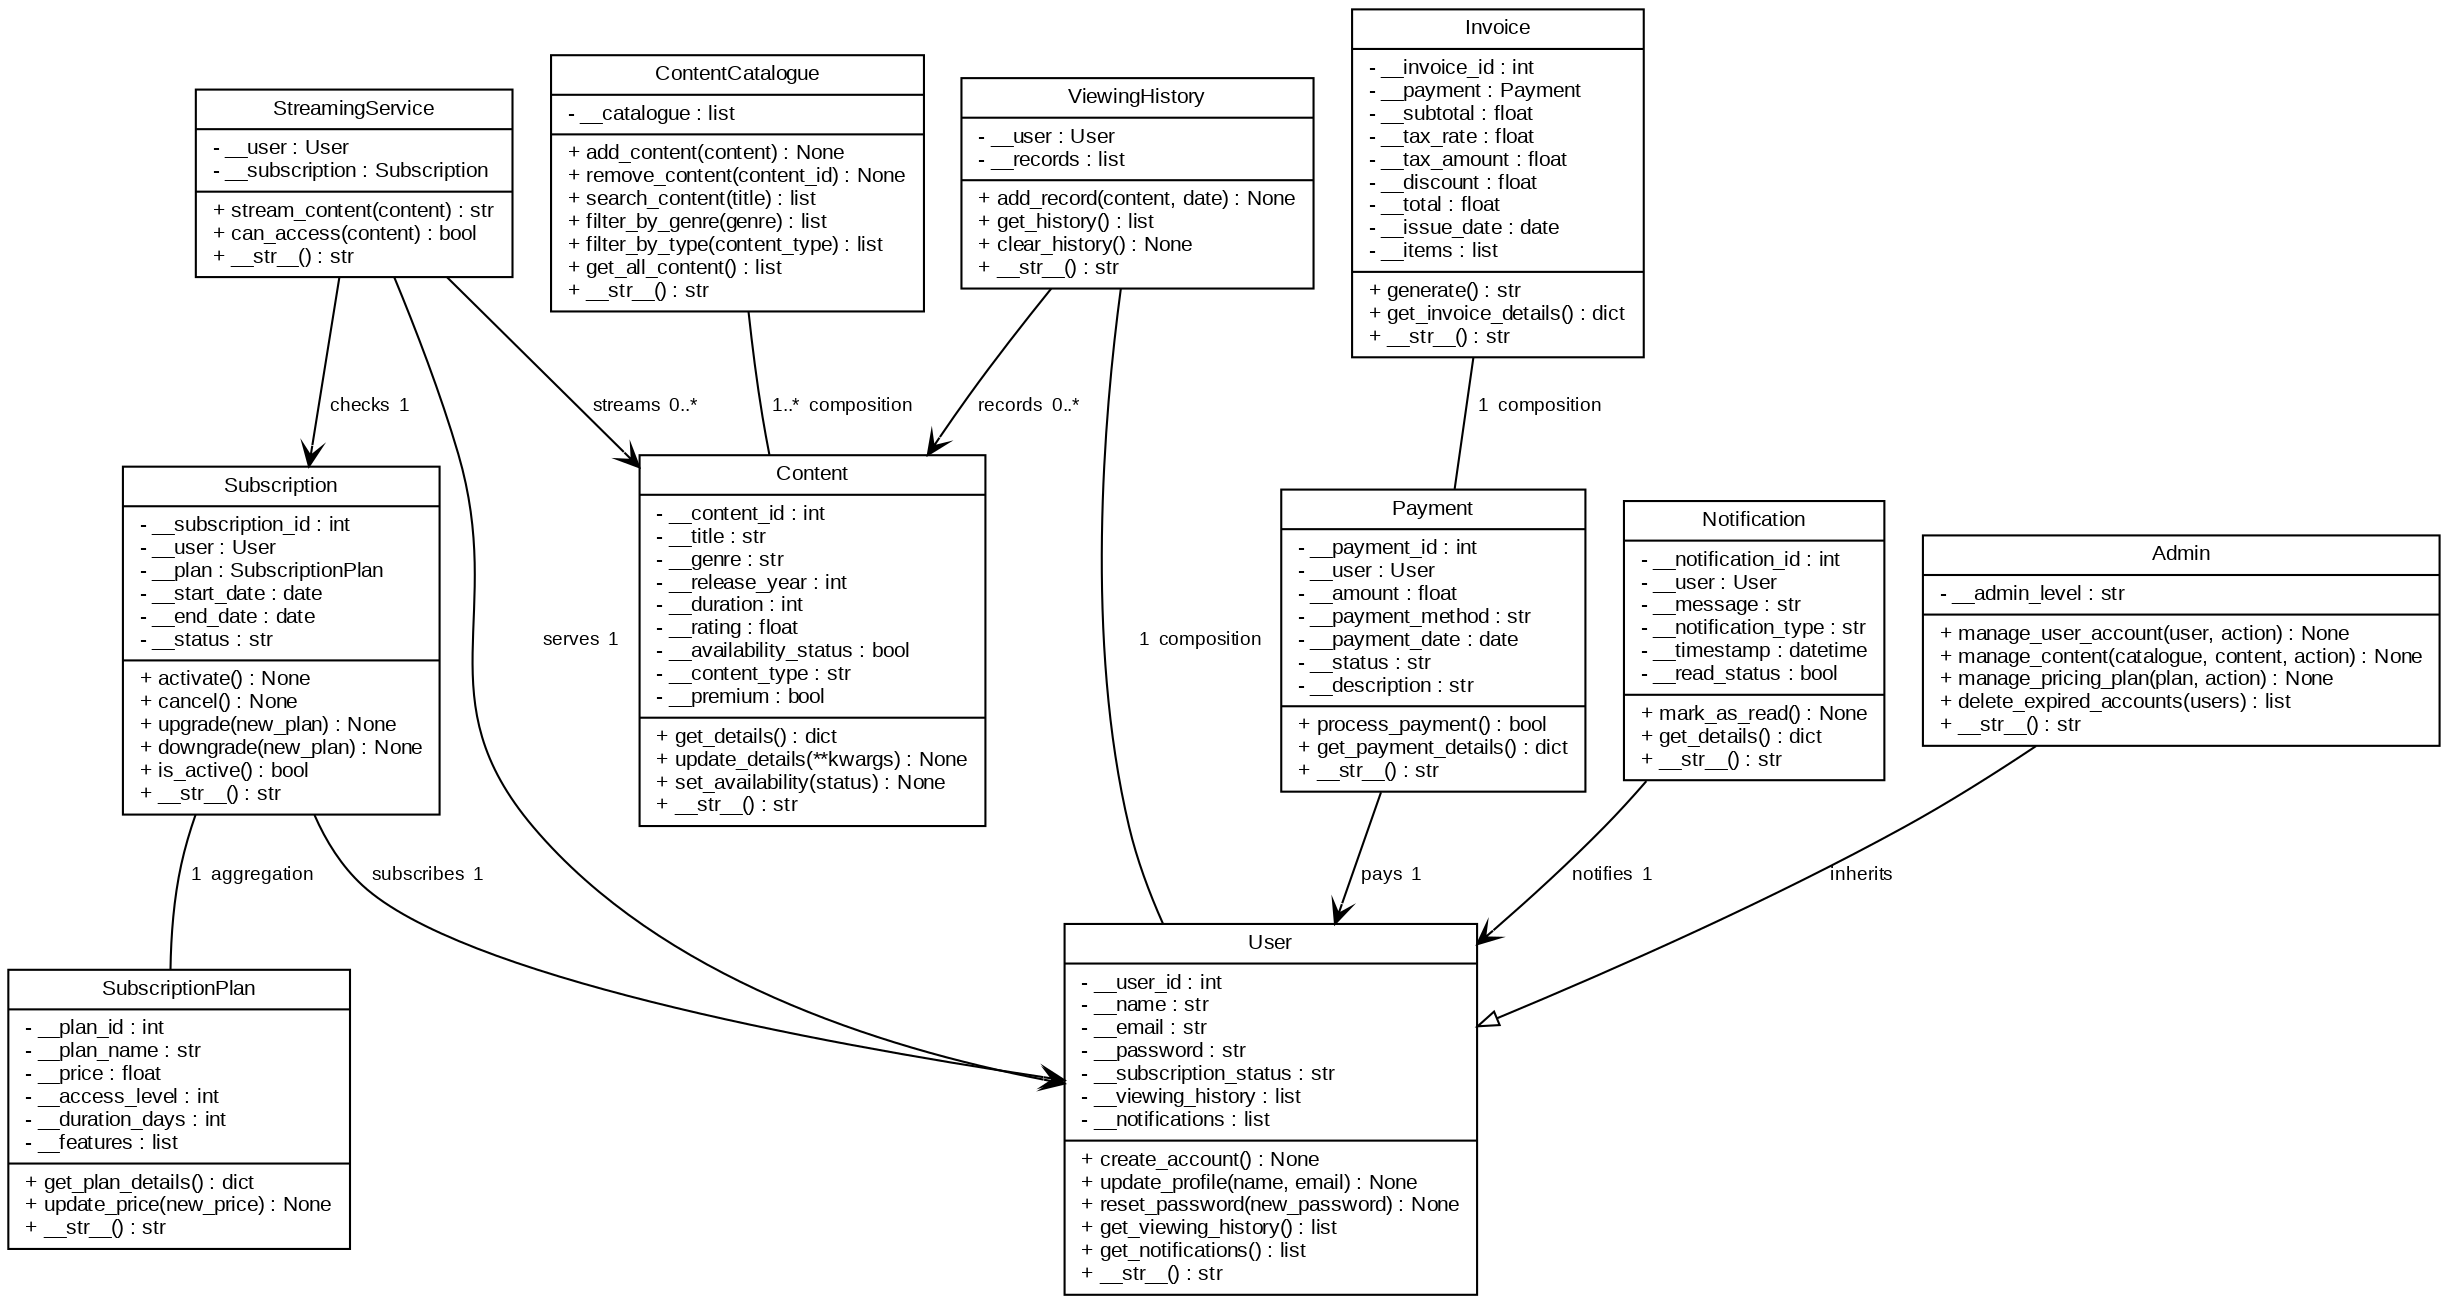

/content/StreamFlix_UML_Class_Diagram.png


✅ UML Class Diagram generated successfully!
📥 Click the link above to download the PNG image.


In [5]:
# ============================================================
# UML Class Diagram Generator for StreamFlix
# Run this in Google Colab to produce a downloadable PNG diagram
# ============================================================

!pip install graphviz

import graphviz

dot = graphviz.Digraph('StreamFlix_UML', format='png')
dot.attr(rankdir='TB', size='28,20', dpi='150')
dot.attr('node', shape='record', fontname='Arial', fontsize='10')
dot.attr('edge', fontname='Arial', fontsize='9')

# ── Class: User ──────────────────────────────────────────────
dot.node('User', '''{User|
- __user_id : int\\l\
- __name : str\\l\
- __email : str\\l\
- __password : str\\l\
- __subscription_status : str\\l\
- __viewing_history : list\\l\
- __notifications : list\\l|
+ create_account() : None\\l\
+ update_profile(name, email) : None\\l\
+ reset_password(new_password) : None\\l\
+ get_viewing_history() : list\\l\
+ get_notifications() : list\\l\
+ __str__() : str\\l}''')

# ── Class: Admin (inherits User) ─────────────────────────────
dot.node('Admin', '''{Admin|
- __admin_level : str\\l|
+ manage_user_account(user, action) : None\\l\
+ manage_content(catalogue, content, action) : None\\l\
+ manage_pricing_plan(plan, action) : None\\l\
+ delete_expired_accounts(users) : list\\l\
+ __str__() : str\\l}''')

# ── Class: Content ───────────────────────────────────────────
dot.node('Content', '''{Content|
- __content_id : int\\l\
- __title : str\\l\
- __genre : str\\l\
- __release_year : int\\l\
- __duration : int\\l\
- __rating : float\\l\
- __availability_status : bool\\l\
- __content_type : str\\l\
- __premium : bool\\l|
+ get_details() : dict\\l\
+ update_details(**kwargs) : None\\l\
+ set_availability(status) : None\\l\
+ __str__() : str\\l}''')

# ── Class: ContentCatalogue ──────────────────────────────────
dot.node('ContentCatalogue', '''{ContentCatalogue|
- __catalogue : list\\l|
+ add_content(content) : None\\l\
+ remove_content(content_id) : None\\l\
+ search_content(title) : list\\l\
+ filter_by_genre(genre) : list\\l\
+ filter_by_type(content_type) : list\\l\
+ get_all_content() : list\\l\
+ __str__() : str\\l}''')

# ── Class: SubscriptionPlan ──────────────────────────────────
dot.node('SubscriptionPlan', '''{SubscriptionPlan|
- __plan_id : int\\l\
- __plan_name : str\\l\
- __price : float\\l\
- __access_level : int\\l\
- __duration_days : int\\l\
- __features : list\\l|
+ get_plan_details() : dict\\l\
+ update_price(new_price) : None\\l\
+ __str__() : str\\l}''')

# ── Class: Subscription ──────────────────────────────────────
dot.node('Subscription', '''{Subscription|
- __subscription_id : int\\l\
- __user : User\\l\
- __plan : SubscriptionPlan\\l\
- __start_date : date\\l\
- __end_date : date\\l\
- __status : str\\l|
+ activate() : None\\l\
+ cancel() : None\\l\
+ upgrade(new_plan) : None\\l\
+ downgrade(new_plan) : None\\l\
+ is_active() : bool\\l\
+ __str__() : str\\l}''')

# ── Class: Payment ───────────────────────────────────────────
dot.node('Payment', '''{Payment|
- __payment_id : int\\l\
- __user : User\\l\
- __amount : float\\l\
- __payment_method : str\\l\
- __payment_date : date\\l\
- __status : str\\l\
- __description : str\\l|
+ process_payment() : bool\\l\
+ get_payment_details() : dict\\l\
+ __str__() : str\\l}''')

# ── Class: Invoice ───────────────────────────────────────────
dot.node('Invoice', '''{Invoice|
- __invoice_id : int\\l\
- __payment : Payment\\l\
- __subtotal : float\\l\
- __tax_rate : float\\l\
- __tax_amount : float\\l\
- __discount : float\\l\
- __total : float\\l\
- __issue_date : date\\l\
- __items : list\\l|
+ generate() : str\\l\
+ get_invoice_details() : dict\\l\
+ __str__() : str\\l}''')

# ── Class: ViewingHistory ────────────────────────────────────
dot.node('ViewingHistory', '''{ViewingHistory|
- __user : User\\l\
- __records : list\\l|
+ add_record(content, date) : None\\l\
+ get_history() : list\\l\
+ clear_history() : None\\l\
+ __str__() : str\\l}''')

# ── Class: Notification ──────────────────────────────────────
dot.node('Notification', '''{Notification|
- __notification_id : int\\l\
- __user : User\\l\
- __message : str\\l\
- __notification_type : str\\l\
- __timestamp : datetime\\l\
- __read_status : bool\\l|
+ mark_as_read() : None\\l\
+ get_details() : dict\\l\
+ __str__() : str\\l}''')

# ── Class: StreamingService ──────────────────────────────────
dot.node('StreamingService', '''{StreamingService|
- __user : User\\l\
- __subscription : Subscription\\l|
+ stream_content(content) : str\\l\
+ can_access(content) : bool\\l\
+ __str__() : str\\l}''')

# ═══════════════════════════════════════════════════════════
# RELATIONSHIPS
# ═══════════════════════════════════════════════════════════

# Inheritance: Admin ──▷ User
dot.edge('Admin', 'User', arrowhead='empty', style='solid', label='  inherits')

# Composition: ContentCatalogue ◆── Content (catalogue owns content)
dot.edge('ContentCatalogue', 'Content', arrowhead='diamond',
         arrowtail='none', dir='back', label='  1..*  composition',
         style='solid', color='black')

# Aggregation: Subscription ◇── SubscriptionPlan
dot.edge('Subscription', 'SubscriptionPlan', arrowhead='odiamond',
         arrowtail='none', dir='back', label='  1  aggregation',
         style='solid', color='black')

# Association: Subscription ── User
dot.edge('Subscription', 'User', arrowhead='open', label='  subscribes  1')

# Composition: Invoice ◆── Payment
dot.edge('Invoice', 'Payment', arrowhead='diamond',
         arrowtail='none', dir='back', label='  1  composition',
         style='solid', color='black')

# Association: Payment ── User
dot.edge('Payment', 'User', arrowhead='open', label='  pays  1')

# Composition: ViewingHistory ◆── User
dot.edge('ViewingHistory', 'User', arrowhead='diamond',
         arrowtail='none', dir='back', label='  1  composition',
         style='solid', color='black')

# Association: ViewingHistory ── Content
dot.edge('ViewingHistory', 'Content', arrowhead='open', label='  records  0..*')

# Association: Notification ── User
dot.edge('Notification', 'User', arrowhead='open', label='  notifies  1')

# Association: StreamingService ── User
dot.edge('StreamingService', 'User', arrowhead='open', label='  serves  1')

# Association: StreamingService ── Subscription
dot.edge('StreamingService', 'Subscription', arrowhead='open', label='  checks  1')

# Association: StreamingService ── Content
dot.edge('StreamingService', 'Content', arrowhead='open', label='  streams  0..*')

# Render
dot.render('StreamFlix_UML_Class_Diagram', cleanup=True)

# For Colab: display inline + download link
from IPython.display import Image, display, FileLink
display(Image('StreamFlix_UML_Class_Diagram.png'))
display(FileLink('StreamFlix_UML_Class_Diagram.png'))

print("\n✅ UML Class Diagram generated successfully!")
print("📥 Click the link above to download the PNG image.")